<a href="https://colab.research.google.com/github/aliya-fatma011/Deep-Learning/blob/main/data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [45]:
img=image.load_img('cat.jpg',target_size=(200,200))

In [46]:
import matplotlib.pyplot as plt

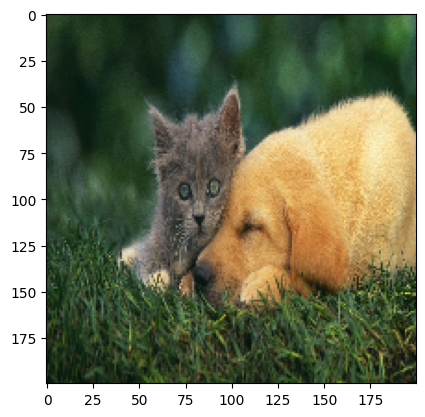

In [47]:
plt.imshow(img)

In [48]:
type(img)

PIL.Image.Image

In [49]:
from textwrap import fill
datagen=ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='constant'


)

In [50]:
img=image.img_to_array(img)

In [51]:
type(img)

numpy.ndarray

In [52]:
img.shape

(200, 200, 3)

In [53]:
input_batch=img.reshape(1,200,200,3)

In [54]:
#for calling only one photo use flow


In [55]:
import os

i=0
# Create the 'aug' directory if it doesn't exist
if not os.path.exists('aug'):
    os.makedirs('aug')

for batch in datagen.flow(input_batch,batch_size=1,save_to_dir='aug'):
  i=i+1
  if i==10:
    break

In [56]:
input_batch.shape

(1, 200, 200, 3)

In [60]:
import tensorflow as tf
tf.keras.layers.RandomFlip("horizontal")
tf.keras.layers.RandomRotation(0.1)
tf.keras.layers.RandomZoom(0.2)

<RandomZoom name=random_zoom, built=False>

In [62]:
import tensorflow as tf

def random_erasing(img):
    h, w, c = img.shape

    erase_h, erase_w = 50, 50

    x = tf.random.uniform([], 0, h - erase_h, dtype=tf.int32)
    y = tf.random.uniform([], 0, w - erase_w, dtype=tf.int32)

    mask = tf.random.uniform((erase_h, erase_w, c), 0, 255)

    img = tf.tensor_scatter_nd_update(
        img,
        indices=[[x+i, y+j] for i in range(erase_h) for j in range(erase_w)],
        updates=tf.reshape(mask, [-1, c])
    )

    return img

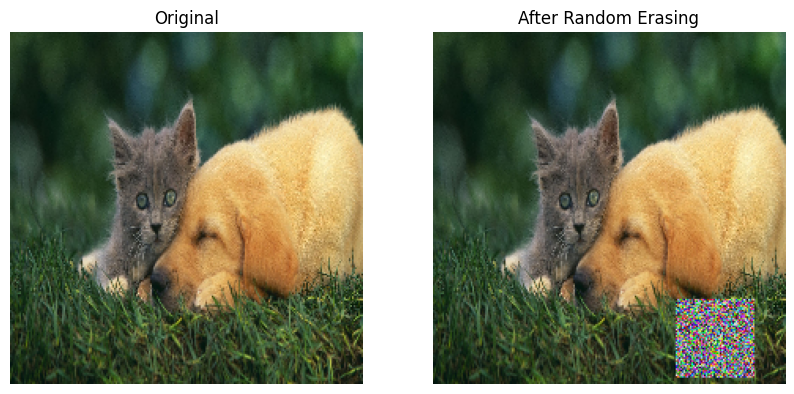

In [65]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Load image
img = load_img("cat.jpg", target_size=(224, 224))
img = img_to_array(img)

# Apply augmentation
aug_img = random_erasing(img)

# Show both images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(aug_img.numpy().astype("uint8"))
plt.title("After Random Erasing")
plt.axis("off")

plt.show()